In [1]:
#setting up the notebook
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [ ]:
#reading the csv file
df= pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/heart_disease_clean.csv')

In [16]:
df.shape

(1316, 9)

In [17]:
#Scaling
from sklearn.preprocessing import StandardScaler

X=df.drop('Result', axis=1)
scalar=StandardScaler()
X_scaled =scalar.fit_transform(X)

In [18]:
#PCA
from sklearn.decomposition import PCA
pca = PCA()
X_2d = pca.fit_transform(X_scaled)              


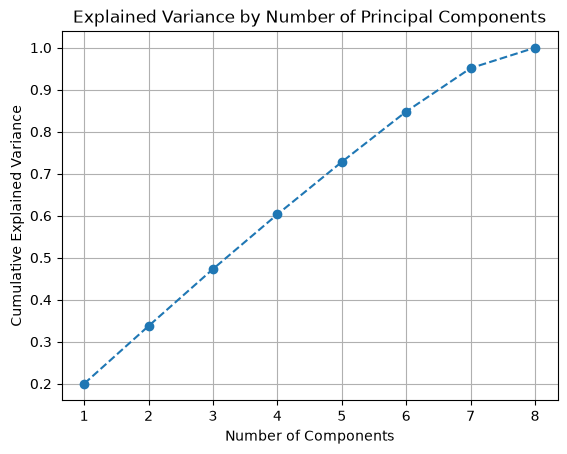

In [19]:
cum_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance against number of components

plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Principal Components')
plt.grid(True)
plt.show()

we cept 7 components to retain 95% of the data the varience and explains it

Text(0.5, 1.0, 'Kmeans Clusters')

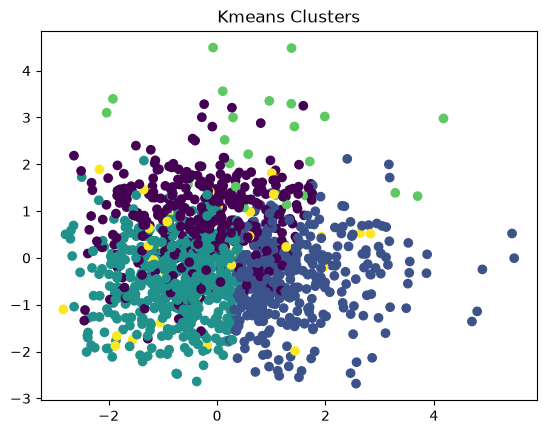

In [20]:
from sklearn.cluster import KMeans

# making 2D df to plot
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)              

#from Day 2
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('Kmeans Clusters')

In [22]:
df['cluster'] = labels
result = df.groupby('cluster').mean(numeric_only=True).round(2)
result['count'] = df['cluster'].value_counts()
display(result)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,count
cluster,,,,,,,,,
0,58.79,0.00,75.24,121.92,70.09,143.14,8.49,0.14,389
1,54.82,0.89,77.14,153.84,86.24,144.43,6.92,0.32,348
2,54.94,1.00,75.54,112.91,64.36,149.03,8.14,0.23,517
3,61.57,0.70,82.00,131.00,73.26,146.78,5.36,7.53,23
4,56.49,0.72,75.31,127.28,71.87,172.13,258.94,0.36,39




Retained 95% of the core data and variance using the top 7 components.

By reducing the dataset to 2 dimensions, we gained the ability to visualize and inspect data distributions and clusters directly on a 2D plot—something impossible with high-dimensional data.

What was the cost:
Loss of 5% Variance: Discarding the remaining components resulted in a minor loss of detailed information (likely representing noise)
Loss of Direct Interpretability: The new components (PC1 and PC2) are no longer represent original features (like age or price), but rather mathematical combinations of multiple variables, making their literal meaning harder to interpret directly.